In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os

# 1. Create the simulated timeline (20 seconds of network traffic)
time_steps = list(range(1, 21))

# Normal baselines
gaming_bw = [5.0] * 20
gaming_lat = [15.0] * 20  # Ping is stable at 15ms

zoom_bw = [10.0] * 14 + [45.0] * 6  # Zoom spikes at second 15 (Someone shared a 4K screen)
zoom_lat = [20.0] * 14 + [25.0] * 6

download_bw = [40.0] * 20 # Constant heavy download
download_lat = [50.0] * 14 + [150.0] * 6 

# The Causal Effect: Because Zoom spiked at T=15, the network switch gets congested.
# This CAUSES the Gaming latency to skyrocket at T=16.
for i in range(15, 20):
    gaming_lat[i] = 180.0  # Game becomes unplayable!

# 2. Build the Dataset
data = []
for t in time_steps:
    data.append({"timestamp": t, "node_id": "server_gaming_01", "bandwidth_used_mbps": gaming_bw[t-1], "latency_ms": gaming_lat[t-1]})
    data.append({"timestamp": t, "node_id": "server_zoom_01", "bandwidth_used_mbps": zoom_bw[t-1], "latency_ms": zoom_lat[t-1]})
    data.append({"timestamp": t, "node_id": "server_download_01", "bandwidth_used_mbps": download_bw[t-1], "latency_ms": download_lat[t-1]})

df = pd.DataFrame(data)

# 3. Save to CSV
os.makedirs('../data', exist_ok=True)
csv_path = '../data/raw_telemetry.csv'
df.to_csv(csv_path, index=False)
print(f"Crime scene data successfully generated at {csv_path}!")

Crime scene data successfully generated at ../data/raw_telemetry.csv!


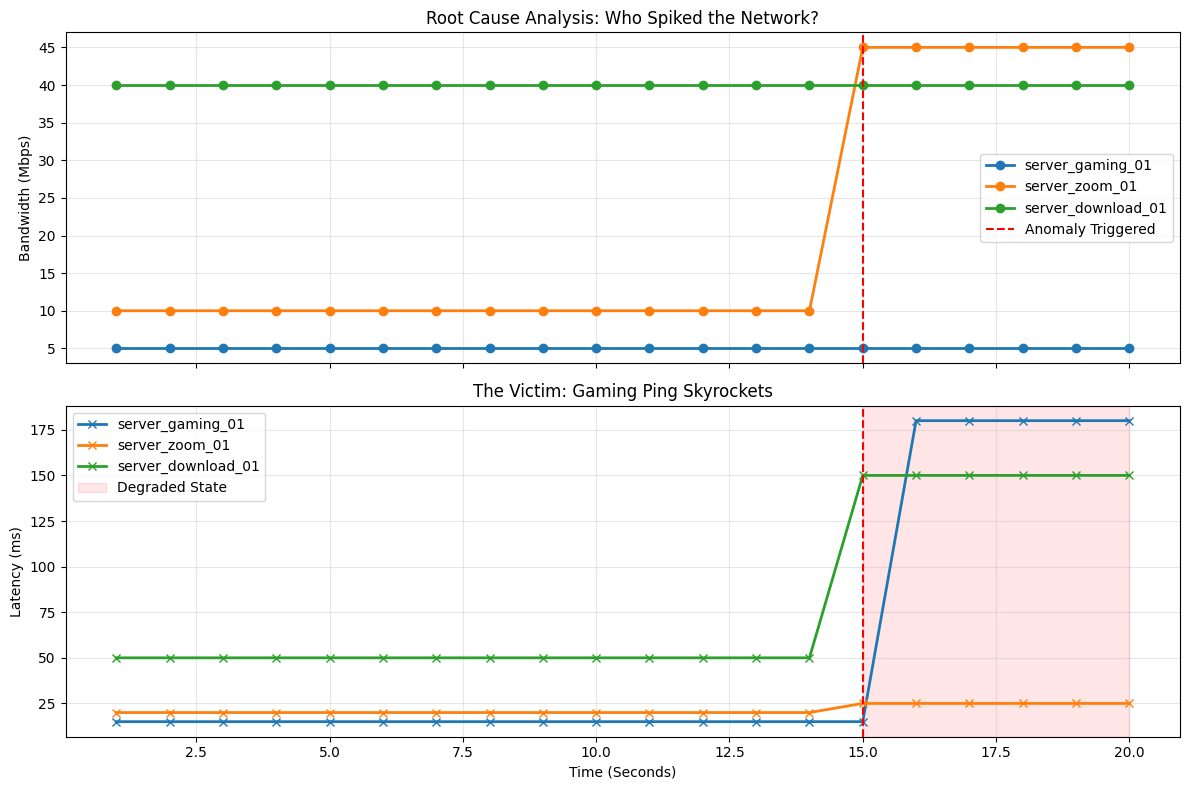

In [2]:
# Load the data we just created
df = pd.read_csv('../data/raw_telemetry.csv')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Graph 1: Bandwidth Timeline
for node in df['node_id'].unique():
    subset = df[df['node_id'] == node]
    ax1.plot(subset['timestamp'], subset['bandwidth_used_mbps'], marker='o', label=node, linewidth=2)

ax1.axvline(x=15, color='red', linestyle='--', label='Anomaly Triggered')
ax1.set_ylabel('Bandwidth (Mbps)')
ax1.set_title('Root Cause Analysis: Who Spiked the Network?')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graph 2: Latency Timeline (The Victim)
for node in df['node_id'].unique():
    subset = df[df['node_id'] == node]
    ax2.plot(subset['timestamp'], subset['latency_ms'], marker='x', label=node, linewidth=2)

ax2.axvline(x=15, color='red', linestyle='--')
ax2.axvspan(15, 20, color='red', alpha=0.1, label='Degraded State')
ax2.set_xlabel('Time (Seconds)')
ax2.set_ylabel('Latency (ms)')
ax2.set_title('The Victim: Gaming Ping Skyrockets')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


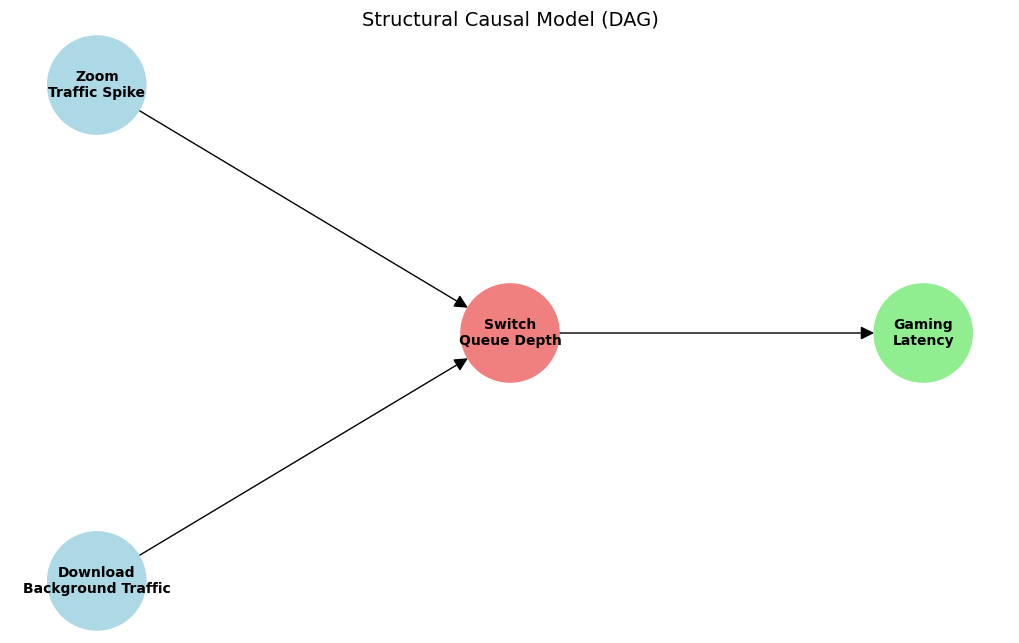

In [3]:
plt.figure(figsize=(10, 6))

# Create a directed graph
G = nx.DiGraph()

# Add nodes representing network physics
G.add_node("Zoom\nTraffic Spike", color='lightblue')
G.add_node("Download\nBackground Traffic", color='lightblue')
G.add_node("Switch\nQueue Depth", color='lightcoral')
G.add_node("Gaming\nLatency", color='lightgreen')

# Add edges (The Causal Links: A causes B)
G.add_edges_from([
    ("Zoom\nTraffic Spike", "Switch\nQueue Depth"),
    ("Download\nBackground Traffic", "Switch\nQueue Depth"),
    ("Switch\nQueue Depth", "Gaming\nLatency")
])

# Draw the graph
pos = {
    "Zoom\nTraffic Spike": (0, 2),
    "Download\nBackground Traffic": (0, 0),
    "Switch\nQueue Depth": (1, 1),
    "Gaming\nLatency": (2, 1)
}

colors = [G.nodes[n]['color'] for n in G.nodes]

nx.draw(G, pos, with_labels=True, node_color=colors, node_size=5000, 
        font_size=10, font_weight='bold', arrows=True, arrowsize=20)

plt.title("Structural Causal Model (DAG)", fontsize=14)
plt.show()


[+] Generating Causal Graph dynamically for victim: GAMING
   -> Victim lives on: server_gaming_01
   -> Isolated Choke Point (Switch): edge_switch_gaming
   -> Causal Graph Built: Found 0 background apps sharing the choke point.


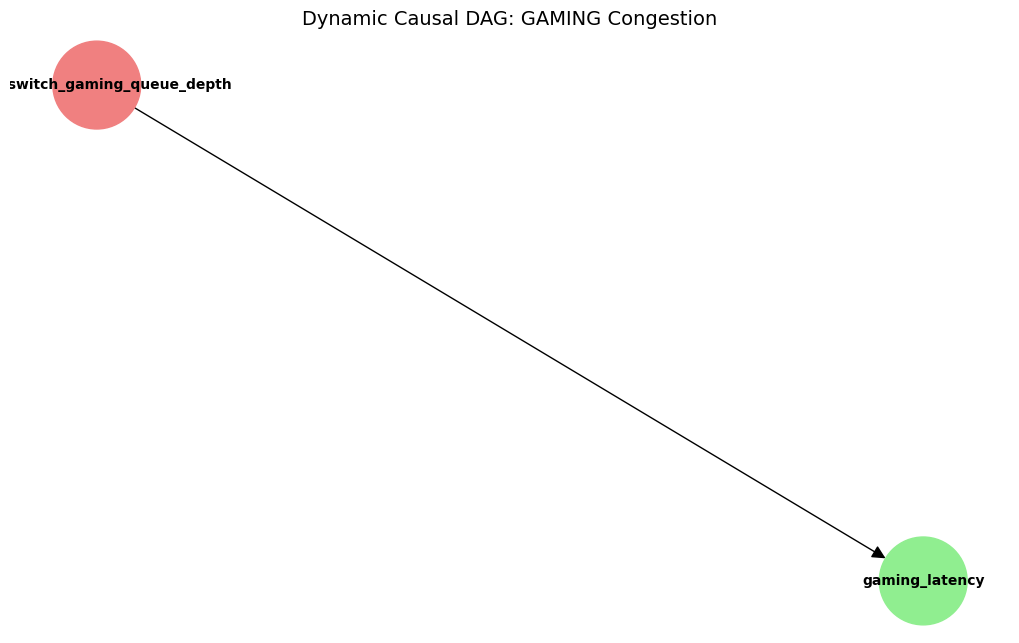

In [2]:
from causal_graph import build_dynamic_causal_dag
dag = build_dynamic_causal_dag(target_app="gaming", visualize=True)